## School Diet

A school wants to estimate the effect of a diet on boys and girls' weight. For this purpose the school first measures the weight of all students at the beginning of the school year (W_{0}) then another measurement is taken six months later (W_{1}).

Generate $n=100$ observations from the following statistical model:

$$
S \sim \text{Bernoulli}(0.5) \\
W_0 \sim \text{Normal}(\mu_i, \sigma_0) \\
\mu_i = \beta_0 + \beta_1 \cdot S_i \\
W_1 = W_0 + \text{Normal}(0, \sigma_e)
$$

- Choose values for the parameters of the model ($\beta_0$, $\beta_1$, $\sigma_0$, $\sigma_e$) that you think are reasonable. Use the `rnorm` function to generate the normally distributed variables for weight at time 0 and time 1, and the `rbinom` function to generate the binary variable for sex (S).
- Visualize the data and adjust your parameters until the generated data looks reasonable. You can use a scatter plot to visualize the relationship between weight at time 0 and time 1, and color the points by sex to see if there are any differences between boys and girls.

In [12]:
suppressPackageStartupMessages(library(tidyverse))

n <- 100

S <- rbinom(n, size = 1, prob = 0.5)
W0 <- rnorm(n, mean = 60 + 15 * S, sd = 5)
W1 <- W0 + rnorm(n, mean = 0, sd = 5)
Y <- W1 - W0

diet <- tibble(S = S, W0 = W0, W1 = W1, Y = Y)

diet |> head()

S,W0,W1,Y
<int>,<dbl>,<dbl>,<dbl>
0,61.21492,53.02880,-8.186122
1,76.61138,75.55981,-1.051572
0,57.74022,63.42945,5.689232
0,61.09928,58.17746,-2.921821
1,81.65366,83.51815,1.864494
1,65.59320,68.36864,2.775438


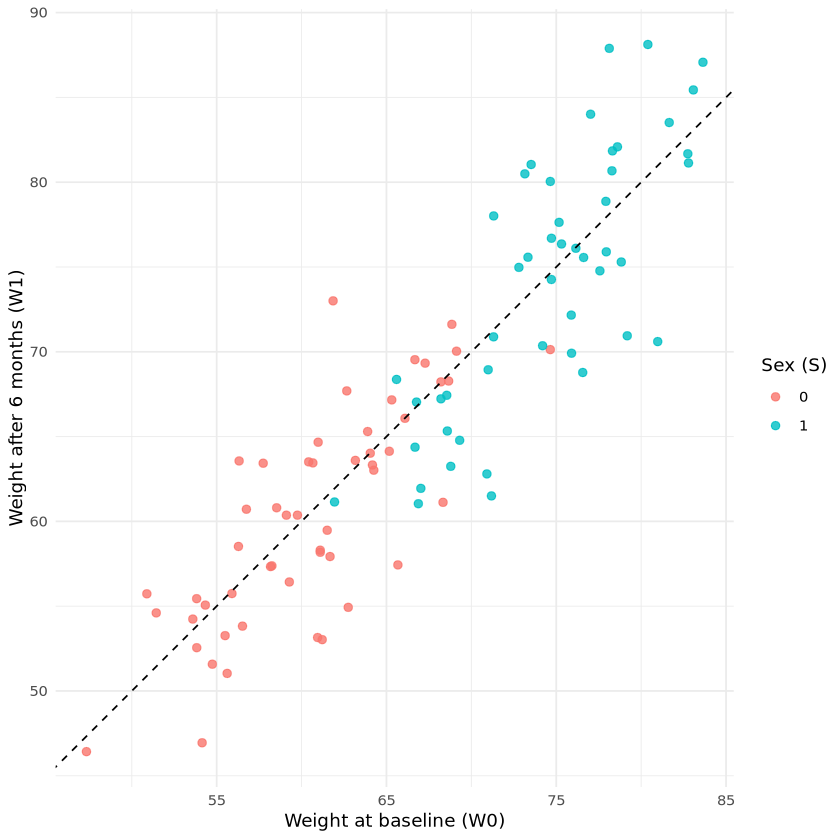

In [13]:
ggplot(diet, aes(x = W0, y = W1, color = factor(S))) +
    geom_point(alpha = 0.8, size = 2) +
    labs(
        x = "Weight at baseline (W0)",
        y = "Weight after 6 months (W1)",
        color = "Sex (S)"
    ) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "black") +
    theme_minimal()

## Analysis

Now pretend that you don't know the data generating process. You only see the end results (the dataset you generated) and you want to analyze it to understand the relationships between weight gain (the difference between the weight after six months and the weight at the beginning of the school year) and sex. In particular you want to research the following question:

```
Is there a difference in weight gain between boys and girls?
```

You want to approach this question by fitting a linear regression model where the dependent variable is the weight gain (W_1 - W_0) and the independent variable is the sex (S).

Should you condition on the initial weight? Do you reach different conclusions if you do or do not condition on the initial weight? Why?

In [14]:
fit_0 <- lm(Y ~ S, data = diet)
fit_0 |> summary()


Call:
lm(formula = Y ~ S, data = diet)

Residuals:
    Min      1Q  Median      3Q     Max 
-9.9570 -2.6152  0.0443  2.7871 11.4030 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  -0.2550     0.6126  -0.416    0.678
S            -0.1600     0.8842  -0.181    0.857

Residual standard error: 4.417 on 98 degrees of freedom
Multiple R-squared:  0.0003342,	Adjusted R-squared:  -0.009866 
F-statistic: 0.03276 on 1 and 98 DF,  p-value: 0.8567


In [15]:
fit_1 <- lm(W1 ~ 1 + S + W0, data = diet)
fit_1 |> summary()


Call:
lm(formula = W1 ~ 1 + S + W0, data = diet)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.1120  -2.5960   0.0766   2.6908  11.3718 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.69333    5.08620  -0.333    0.740    
S           -0.49050    1.46104  -0.336    0.738    
W0           1.02376    0.08339  12.277   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4.438 on 97 degrees of freedom
Multiple R-squared:  0.8009,	Adjusted R-squared:  0.7968 
F-statistic: 195.1 on 2 and 97 DF,  p-value: < 2.2e-16
